# CNN - Convolutional Neural Network (PyTorch)

A CNN replaces some fully-connected layers with **convolutional** layers that slide
small learned filters across an image, exploiting the fact that nearby pixels are
related. This needs far fewer parameters than a plain [`ANN`](../02_ANN) for image
data and tends to generalize better.

We classify the same handwritten digits as in `02_ANN`, but this time keep them as
real 8x8 **images** (`sklearn.datasets.load_digits`) instead of flattening them, and
feed them through a small Conv -> Pool -> Conv -> Pool -> Dense network.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

torch.manual_seed(0)

In [2]:
digits = load_digits()
X = digits.images / 16.0  # (1797, 8, 8) pixel intensities, scaled to [0, 1]
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# add a channel dimension: (N, 1, 8, 8) — PyTorch conv layers expect (N, C, H, W)
X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)
X_train.shape

torch.Size([1437, 1, 8, 8])

In [3]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)   # 8x8 -> 8x8, 8 filters
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)  # 4x4 -> 4x4, 16 filters
        self.pool = nn.MaxPool2d(2)                              # halves H and W
        self.fc = nn.Linear(16 * 2 * 2, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # -> (N, 8, 4, 4)
        x = self.pool(torch.relu(self.conv2(x)))   # -> (N, 16, 2, 2)
        x = x.flatten(1)
        return self.fc(x)


model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [4]:
losses = []
for epoch in range(30):
    optimizer.zero_grad()
    loss = criterion(model(X_train), y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 5 == 0:
        print(f"epoch {epoch+1:3d}  loss {loss.item():.4f}")

epoch   5  loss 2.1886
epoch  10  loss 1.8575
epoch  15  loss 1.2366
epoch  20  loss 0.6052
epoch  25  loss 0.3201
epoch  30  loss 0.2034


Test accuracy: 0.942


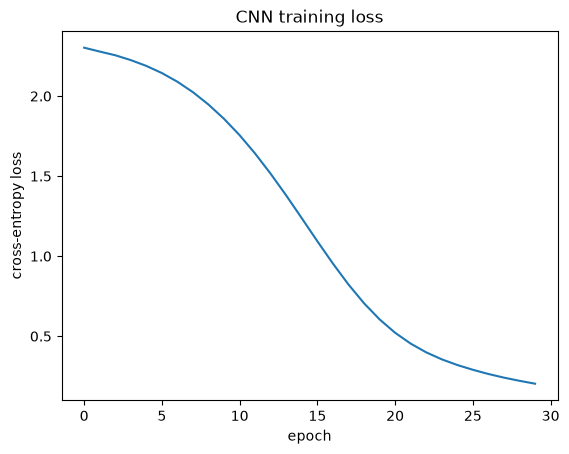

In [5]:
with torch.no_grad():
    accuracy = (model(X_test).argmax(dim=1) == y_test).float().mean().item()
print(f"Test accuracy: {accuracy:.3f}")

plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.title("CNN training loss")
plt.show()